# Minimal Viable Pixelator – Batch Test
Processes all images in `test_cases/` and saves the block‑pixelated results to `outputs/`.

In [9]:
import cv2
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
def block_representative_color(block, method="mean"):
    """
    Compute a single color for a block of pixels.
    Supports 'mean', 'median', 'center', 'majority'.
    """
    if block.ndim == 2:  # grayscale
        if method == "mean":
            return int(np.mean(block))
        elif method == "median":
            return int(np.median(block))
        elif method == "center":
            return int(block[block.shape[0] // 2, block.shape[1] // 2])
        elif method == "majority":
            vals, counts = np.unique(block, return_counts=True)
            return int(vals[np.argmax(counts)])
        else:
            raise ValueError(f"Unknown method: {method}")
    else:  # color
        if method in ["mean", "median"]:
            func = np.mean if method == "mean" else np.median
            color = func(block.reshape(-1, 3), axis=0).astype(np.uint8)
            return tuple(color)
        elif method == "center":
            return tuple(block[block.shape[0] // 2, block.shape[1] // 2])
        elif method == "majority":
            pixels = block.reshape(-1, 3)
            dtype = np.dtype((np.void, pixels.dtype.itemsize * 3))
            structured = pixels.view(dtype).reshape(-1)
            unique, counts = np.unique(structured, return_counts=True)
            most_common = unique[np.argmax(counts)].view(np.uint8).reshape(3)
            return tuple(most_common)
        else:
            raise ValueError(f"Unknown method: {method}")

def pixelate_image(image, block_size, method="mean"):
    """
    Segment image into blocks and replace each block with its representative color.
    """
    if isinstance(block_size, int):
        bh = bw = block_size
    else:
        bh, bw = block_size

    out = np.zeros_like(image)
    h, w = image.shape[:2]

    for y in range(0, h, bh):
        for x in range(0, w, bw):
            y_end = min(y + bh, h)
            x_end = min(x + bw, w)
            block = image[y:y_end, x:x_end]
            color = block_representative_color(block, method)
            out[y:y_end, x:x_end] = color

    return out

## ⚙️ Configuration
Adjust block size and sampling method here.

In [11]:
BLOCK_SIZE = 5          # pixels per block (square)
METHOD = "mean"          # "mean", "median", "center", "majority"

INPUT_DIR = Path("test_cases")
OUTPUT_DIR = Path("outputs")

# Supported image extensions
EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp", ".tiff")

# Create output directory if it doesn't exist
OUTPUT_DIR.mkdir(exist_ok=True)

## 🔄 Batch Processing

Processing albert.jpg ...


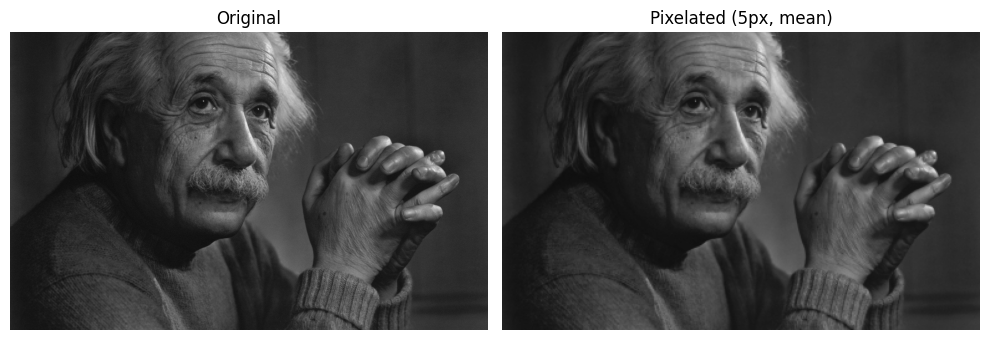

Processing gradient_descending.png ...


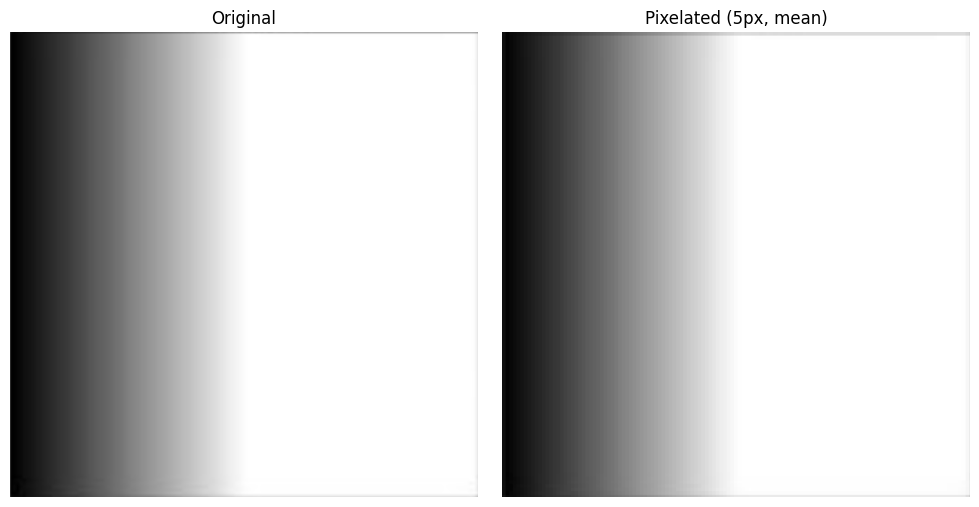

Processing hatsune_miku.jpg ...


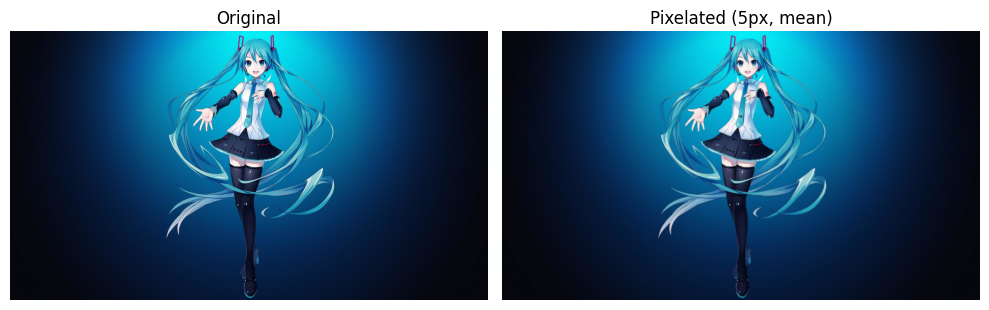

Processing mona_lisa.jpg ...


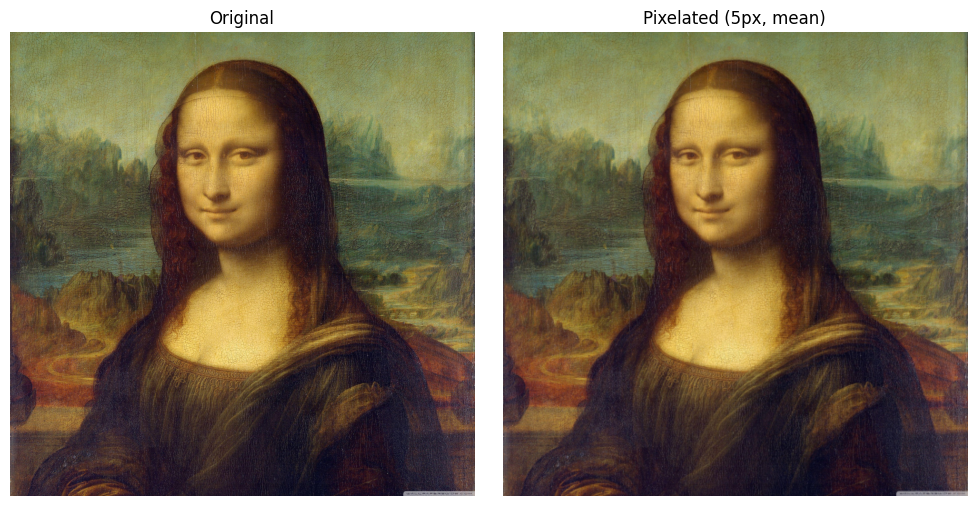

Processing test_case.png ...


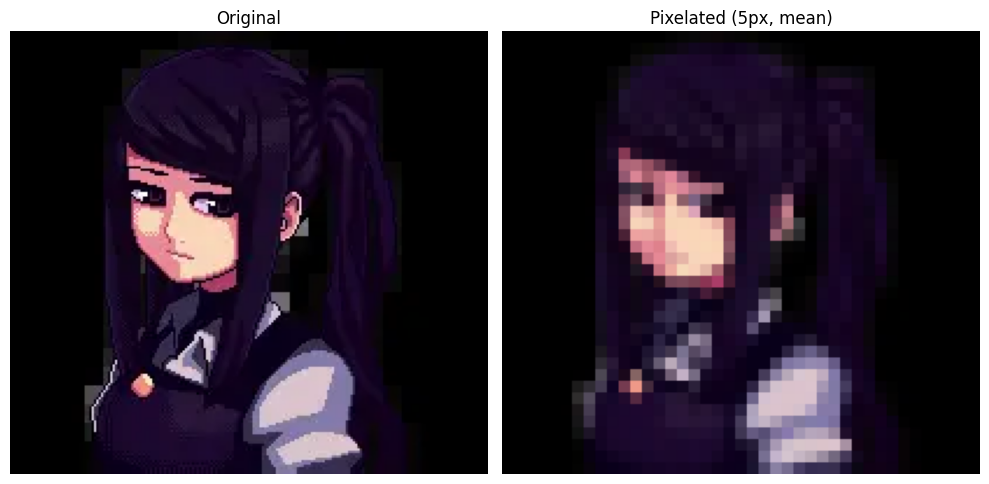

Processing van_gogh_starsky.jpg ...


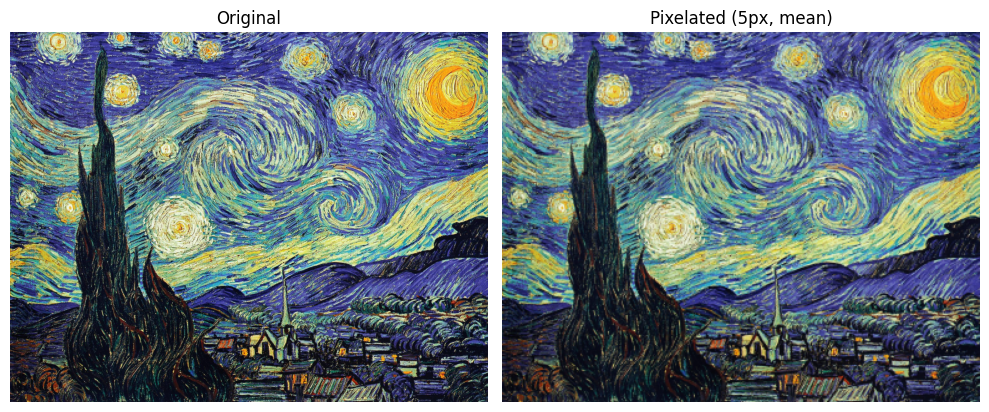

Processing why_are_you_sitting.jpg ...


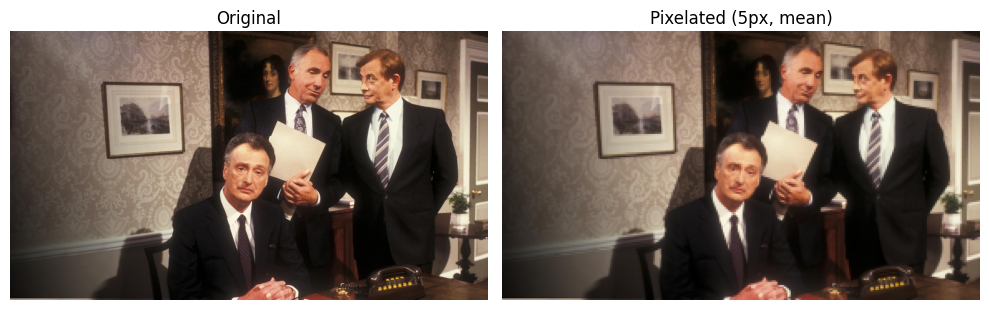

Processing why_are_you_sitting_palette_ver1_16colors.png ...


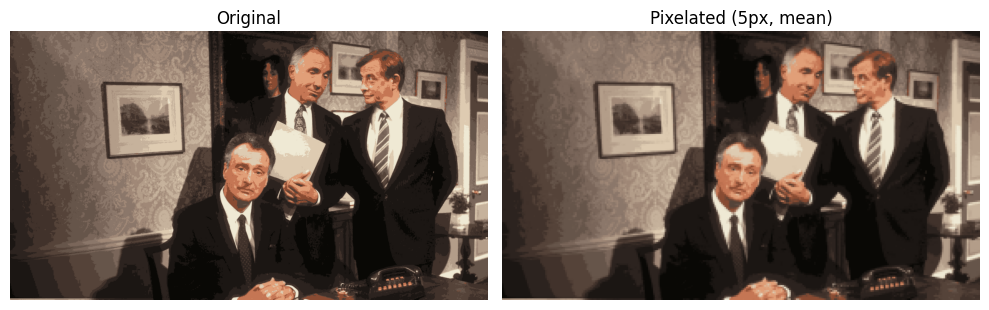

✅ All done. Check the 'outputs' folder.


In [12]:
for img_path in sorted(INPUT_DIR.glob("*")):
    if img_path.suffix.lower() not in EXTENSIONS:
        continue

    # Read image
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print(f"⚠️  Skipping non‑image file: {img_path.name}")
        continue

    print(f"Processing {img_path.name} ...")

    # Pixelate
    pixelated_bgr = pixelate_image(img_bgr, BLOCK_SIZE, METHOD)

    # Save result
    out_name = img_path.stem + f"_px{BLOCK_SIZE}_{METHOD}.png"
    out_path = OUTPUT_DIR / out_name
    cv2.imwrite(str(out_path), pixelated_bgr)

    # ---- Display side‑by‑side in notebook ----
    # Convert BGR to RGB for correct colors
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pixelated_rgb = cv2.cvtColor(pixelated_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(pixelated_rgb)
    plt.title(f"Pixelated ({BLOCK_SIZE}px, {METHOD})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

print("✅ All done. Check the 'outputs' folder.")